In [1]:
from pathlib import Path
from ase.io import read
from ase import Atoms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

O objetivo deste Jupyter Notebook será o de analisar a composição do dataset utilizado pra produzir as bandas do modelo007, no qual utilizou-se alguns subsets e um filtro de força de 20 e $\text{eV}/\AA$.

<div align="center">

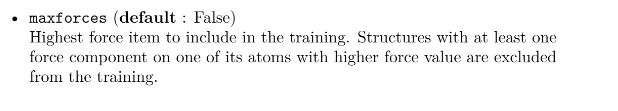

</div>

In [7]:
data = Path("/home/jvc/ZnO_database/data")

traininig = data / "dataset" / "01_LDA_dataset_filtered" / "train"
subsets_names = [
    "LDA_118_XSF",
    "LDA_214_XSF",
    "LDA_333_XSF",
    "LDA_normal_modes_3x3x3",
]

subsets: list[Path] = [data / f"subsets/{s}" for s in subsets_names]
xsf_dirs: list[Path] = [traininig, *subsets]
all_files: list[Path] = [file for d in xsf_dirs for file in sorted(d.glob("*.xsf"))]

In [8]:
atoms = [read(f) for f in all_files]

In [14]:

def get_force_df(atoms: list[Atoms], filenames: list[Path]) -> pd.DataFrame:

    dados_forcas = []

    for i, snapshot in enumerate(atoms):
        forces = snapshot.get_forces()

        for idx_atomo, vetor_forca in enumerate(forces):
            symbols: list[str] = snapshot.get_chemical_symbols()
            dados_forcas.append(
                { 'filename': filenames[i].name,                 # Número do snapshot (0, 1, 2...)
                'atom': symbols[idx_atomo],                 # Índice do átomo dentro do frame
                'fx': vetor_forca[0],
                'fy': vetor_forca[1],
                'fz': vetor_forca[2]}
            )

    df_forcas = pd.DataFrame(dados_forcas)
    return df_forcas     

In [15]:
forces = get_force_df(atoms=atoms, filenames=all_files)

In [105]:
forces["atomo_valido"] = (forces.iloc[:,2:].abs() <= 20).all(axis=1)

print("Amostra do Dataframe filtrando por força no átomo:\n")
display(forces.sample(10))

df_estruturas = forces.groupby("filename")[["atomo_valido"]].all().reset_index()
df_estruturas = df_estruturas.rename(columns={"atomo_valido":"estrutura_valida"})

print("Amostra do Dataframe filtrando por estrutura válida:\n")
display(df_estruturas)

Amostra do Dataframe filtrando por força no átomo:



,filename,atom,fx,fy,fz,atomo_valido
108831,LDA-0049-ZnO-333-fa1.05-fc1.05.xsf,O,0.000000,-0.000000,-0.199843,True
41149,2650-LDA-ZnO-3.32-1.61-313-0.04.xsf,Zn,-14.206268,5.339535,12.955443,True
83942,5512-LDA-ZnO-3.20-1.61-331-0.12.xsf,O,85.841384,92.514300,-45.705976,False
38801,2503-LDA-ZnO-3.26-1.61-221-0.04.xsf,Zn,3.900880,10.955802,-1.536317,True
94201,6195-LDA-ZnO-3.52-1.54-221-0.12.xsf,Zn,17.370266,-13.513254,9.452088,True
51840,3352-LDA-ZnO-2.94-1.57-313-0.06.xsf,Zn,28.302316,46.723228,-9.382090,False
14144,0897-LDA-ZnO-3.26-1.51-331.xsf,Zn,-0.000000,0.000000,-20.620271,False
16545,1058-LDA-ZnO-3.32-1.57-212.xsf,Zn,-0.000014,-0.000007,-2.736873,True
3470,0221-LDA-ZnO-2.94-1.61-331.xsf,O,0.000000,-0.000056,0.146979,True
19098,1222-LDA-ZnO-3.39-1.61-331.xsf,O,0.000028,0.000014,-0.243003,True


Amostra do Dataframe filtrando por estrutura válida:



,filename,estrutura_valida
0,0001-LDA-ZnO-2.88-1.44-111.xsf,False
1,0003-LDA-ZnO-2.88-1.44-113.xsf,False
2,0005-LDA-ZnO-2.88-1.44-212.xsf,False
3,0007-LDA-ZnO-2.88-1.44-221.xsf,False
4,0009-LDA-ZnO-2.88-1.44-311.xsf,False
...,...,...
5296,LDA-0238-ZnO-118-fa1.10-fc1.06-n0.040.out.xsf,False
5297,LDA-0239-ZnO-118-fa1.10-fc1.08-n0.000.out.xsf,True
5298,LDA-0240-ZnO-118-fa1.10-fc1.08-n0.040.out.xsf,False
5299,LDA-0241-ZnO-118-fa1.10-fc1.10-n0.000.out.xsf,True


In [165]:
count_estruturas = df_estruturas['estrutura_valida'].value_counts()
count_estruturas.index = ("Inválidas", "Válidas")

print(f"Contagem estruturas:\n{count_estruturas}\n")



Contagem estruturas:
Inválidas    4089
Válidas      1212
Name: count, dtype: int64



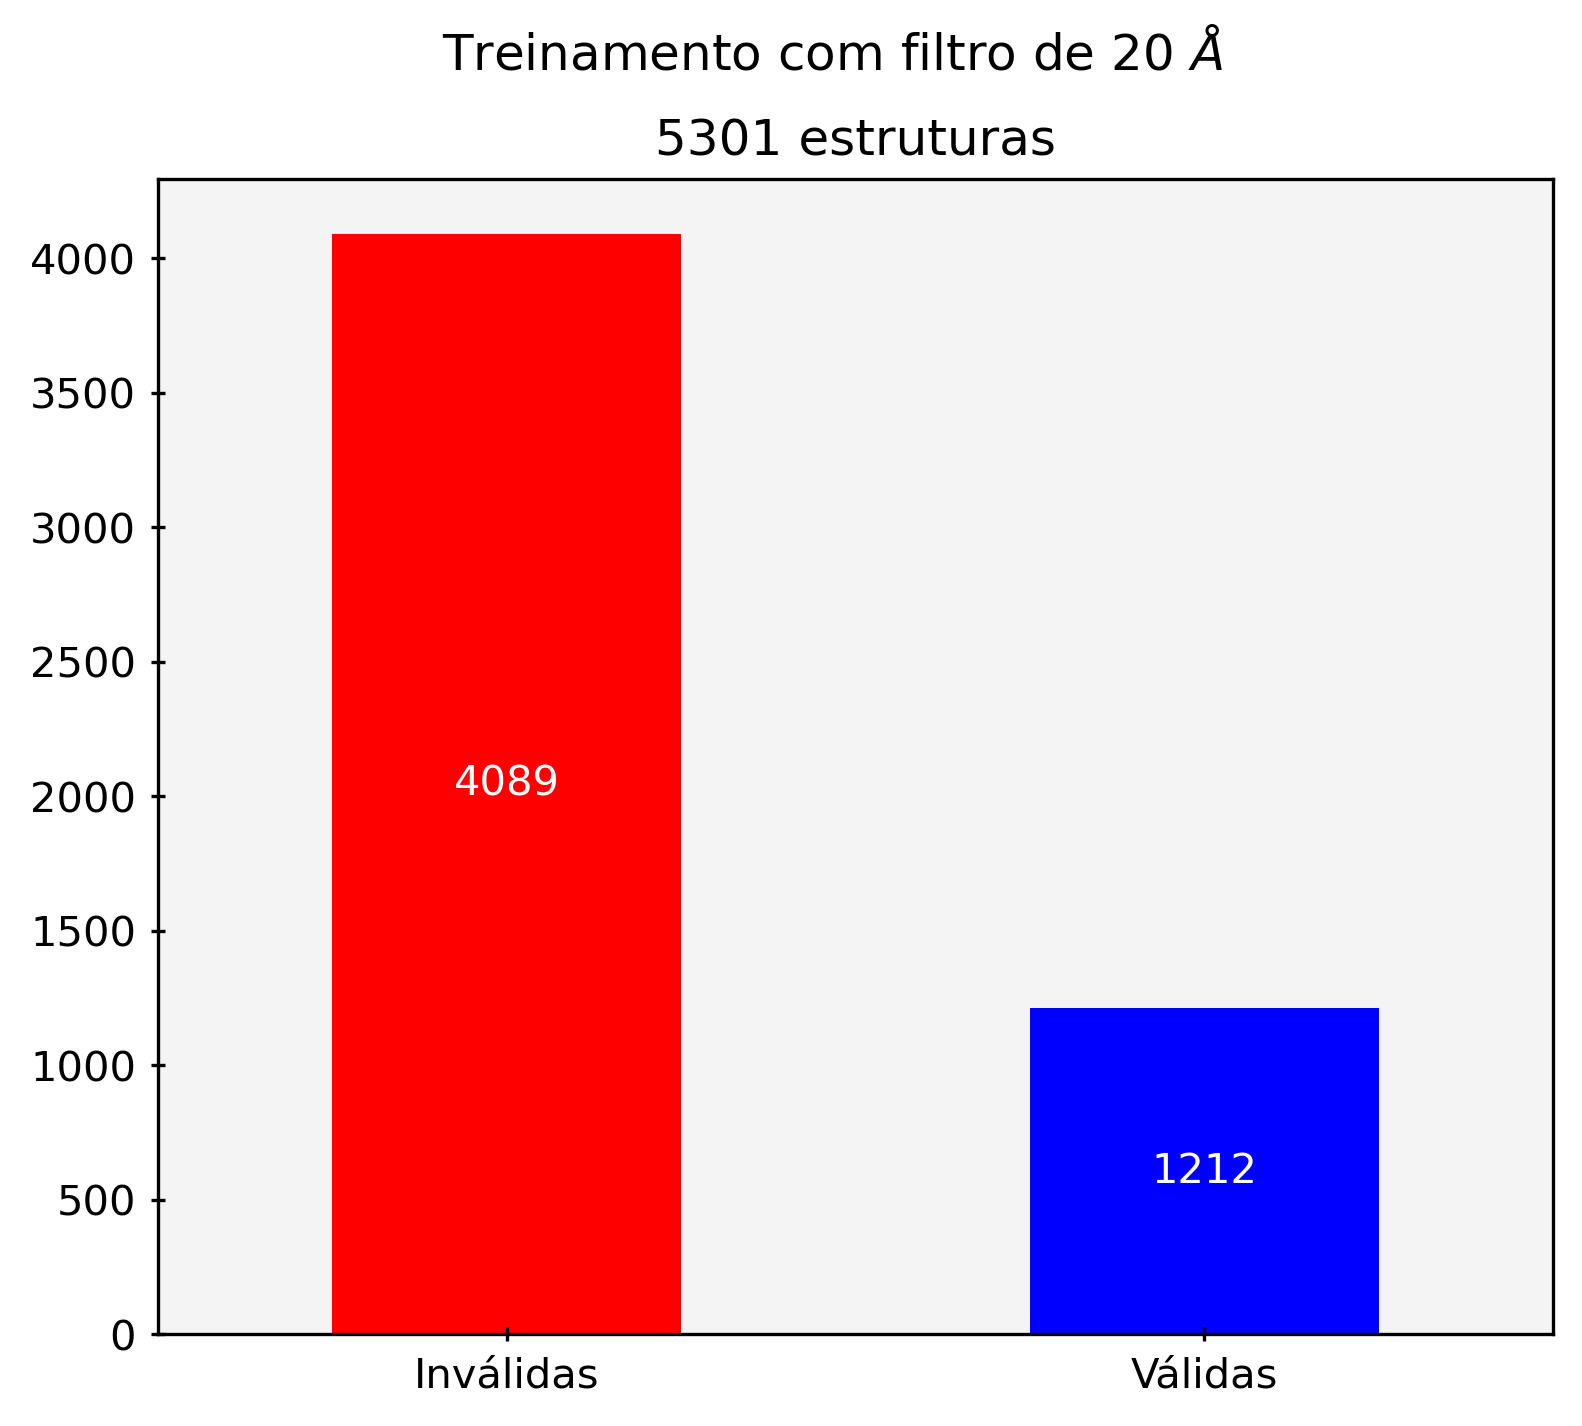

In [151]:
fig, ax = plt.subplots(figsize=(6,5), dpi=300)
fig.suptitle(r"Treinamento com filtro de 20 $\AA$")
ax.set_title(f"{df_estruturas.shape[0]} estruturas")
ax.set_facecolor("#f4f4f4")
count_estruturas.plot(kind='bar',ax=ax,rot=0, color=["red","blue"])
ax.bar_label(container=ax.containers[0], label_type='center', color='white')
ax.tick_params(direction='inout')
plt.show()

---